# **Урок 12**: Диффузионные модели

В этом уроке будем разбираться с генерацией в CV и диффузионными моделями.
План таков:

1. Вспоминаем GAN, тыкаем несколько моделей.
2. Пишем DDPM самостоятельно, разбираемся с математикой диффузии.
3. Запускаем другие диффузионки из лекции, тыкаем их на предмет качества.

## GAN

Напомним, как работает GAN.

Есть две сети, каждая из которых пытается обмануть другую:

1. **Генератор** пытается создать картинку, которую **дискриминатор** не отличит от настоящей.
2. **Дискриминатор** пытается правильно отличать фальшивки от настоящих картинок.

Схематично это выглядит так:

![GAN](img/gan_diagram.svg)

_Источник: [developers.google.com](https://developers.google.com/machine-learning/gan/gan_structure)._

Идея GAN достаточно размытая, поэтому конкретных реализаций много.

## Диффузионные модели на примере DDPM

В лекции мы говорили про диффузионные модели.
Теперь мы будем эти диффузионные модели реализовывать.
Мы напишем DDPM, обучим на MNIST и посмотрим качество генерации.

### Теория

Напомним кратко, что было на лекции:
1. Во время обучения мы зашумляем картинки (для всех $t=0..1000$) и учим модель предсказывать незашумлённую картинку на каждом $t$.
2. Во время инференса мы семплируем шум $\varepsilon \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$, делаем $T=1000$ проходов модели и получаем расшумлённую картинку. При этом после каждого прохода мы впрыскиваем гауссов шум.
3. Все зашумления проходят постепенно. Скажем, берём 99% от исходной картинки и 1% от шума.

В псевдокоде обучение и инференс делаются так:
![Обучение и инференс диффузионной модели](img/train_inference.png)

_Источник: [статья DDPM](https://arxiv.org/abs/2006.11239)._

### Практика

Будем решать задачу по шагам:

1. Разберёмся с датасетом, даталоадером.
2. Разберёмся с подсчётом коэффициентов $\alpha_t$, $\beta_t$, $\bar{\alpha}_t$.
3. Сделаем зашумитель изображений, который будет семплировать $x_t \sim q(x_t | x_0)$.
4. Сделаем расшумитель, который будет семплировать $x_{t - 1}$ по $x_t$.
5. Обучим на картинках.
6. Сделаем инференс, посмотрим качество.

#### Датасет, даталоадер

Возьмём MNIST для простоты и скорости.

In [1]:
import albumentations as A
import numpy as np
import torch
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import MNIST

forward_transforms = A.Compose(
    [
        A.Resize(28, 28),
        # Приводим в отрезок [0, 1]
        A.Normalize(mean=0.5, std=0.5, max_pixel_value=255.0),
        # И нормализуем на среднее и дисперсию
        A.Normalize(mean=0.1307, std=0.3081, max_pixel_value=1.0),
        ToTensorV2(),
    ]
)
# Обратное преобразование — из [-1, 1] в [0, 255] (для визуализации)
backward_transforms = A.Compose([A.Normalize(max_pixel_value=1, mean=-1, std=2 / 255)])


class MnistDataset(Dataset):
    def __init__(self, train: bool = True):
        super().__init__()
        self.mnist = MNIST("data", train=train, download=True)

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        image, target = self.mnist[index]
        image = np.array(image)
        image = forward_transforms(image=image)["image"]
        return image, target


train_dataset = MnistDataset(train=True)
print(train_dataset[1][0].max())
print(train_dataset[1][0].min())
print(backward_transforms(image=train_dataset[1][0].numpy())["image"].max())

tensor(2.8215)
tensor(-3.6699)
487.23953


In [2]:
import os
import random


def enable_determinism():
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True)


def fix_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.mps.manual_seed(seed)


# https://pytorch.org/docs/stable/notes/randomness.html#dataloader
def seed_worker(_):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


seed = 42
enable_determinism()
fix_seeds(seed)
generator = torch.Generator()
generator.manual_seed(seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    num_workers=16,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=generator,
)

#### Коэффициенты

Напомним, что это и зачем нам это нужно.

Коэффициент $\beta_t$ нужен для того, чтобы после $t$ зашумлений у итогового распределения дисперсия оставалась единичной (или близкой к ней).
В нашем случае зашумление будет идти по схеме:
$$
q(x_t | x_{t - 1}) = \mathcal{N} (x_t; \sqrt{1 - \beta_t} x_{t - 1}, \beta_t I)
$$

Для удобства вводят букву $\alpha_t = 1 - \beta_t$.

Формула выше задаёт правило, как из прошлого элемента получить следующий.
Эту цепочку можно раскрыть и получить формулу сразу на $x_t$ из $x_0$:
$$
q(x_t | x_0) = \mathcal{N} (x_t; \sqrt{\bar{\alpha}_t} x_0, (1 - \bar{\alpha}_t) I)
$$
где $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$.

Попробуйте вывести этот факт самостоятельно.

Сделайте reparametrization trick: $\mathcal{N} (a, \sigma^2) = a + \mathcal{N} (0, \sigma^2)$.
Затем 2 шага в этой цепочке.
Матожидание сразу получится, а с дисперсией разберитесь честно — вспомните, что сумма гауссиан есть гауссиана с дисперсиями $\sigma_1^2 + \sigma_2^2$, и причешите выражение.

<details>
<summary>Вывод</summary>

Сначала вспомним _reparametrization trick_: $\mathcal{N} (a, \sigma^2) = a + \mathcal{N} (0, \sigma^2)$.

В нашем случае $x_t = \sqrt{1 - \beta_t} x_{t - 1} + \sqrt{\beta_t}\varepsilon_t$,
где $\varepsilon_t \sim \mathcal{N} (0, I)$.

$$
x_t = \sqrt{1 - \beta_t} \underbrace{x_{t - 1}}_\text{раскроем} + \sqrt{\beta_t}\varepsilon_t
= \sqrt{\alpha_t} (\sqrt{\alpha_{t - 1}} x_{t - 2} + \sqrt{1 - \alpha_{t - 1}} \varepsilon_{t - 1}) + \sqrt{1 - \alpha_t} \varepsilon_t \\
= \underbrace{\sqrt{\alpha_t \alpha_{t - 1}}}_{\text{узнаем вид } \bar{\alpha_t}} x_{t - 2} + \underbrace{\sqrt{\alpha_t (1 - \alpha_{t - 1})} \varepsilon_{t - 1} + \sqrt{1 - \alpha_t} \varepsilon_t}_{\sqrt{\alpha_t (1 - \alpha_{t - 1})} \mathcal{N} (0, 1) + \sqrt{1 - \alpha_t} \mathcal{N} (0, 1)}
$$

Сложим гауссианы:
$$
\sqrt{\alpha_t (1 - \alpha_{t - 1})} \mathcal{N} (0, 1) + \sqrt{1 - \alpha_t} \mathcal{N} (0, 1) = \mathcal{N} (0, \alpha_t (1 - \alpha_{t - 1})) + \mathcal{N} (0, 1 - \alpha_t) \\
= \mathcal{N}(0, \alpha_t (\cancel{1} - \alpha_{t - 1}) + 1 - \cancel{\alpha_t}) \\
= \mathcal{N} (0, \underbrace{1 - \alpha_t \alpha_{t - 1}}_{\text{это наш } 1 - \bar \alpha_t})
$$

Продолжая раскрывать, придём в итоге к искомой формуле.

Отсюда, кстати, видно, что если шум будет не гауссовым, то формула перестанет работать.

</details>

Итого: нам надо закодить $\alpha_t$, $\sqrt{\alpha_t}$, $\beta_t$, $\bar{\alpha_t}$, $\sqrt{\bar{\alpha_t}}$.

In [3]:
from dataclasses import dataclass


@dataclass
class Coeffs:
    alphas: torch.Tensor
    betas: torch.Tensor
    sqrt_betas: torch.Tensor
    sqrt_alphas: torch.Tensor
    alphas_hat: torch.Tensor
    sqrt_alphas_hat: torch.Tensor
    sqrt_1m_alphas_hat: torch.Tensor


def get_coeffs(
    T: int = 1000, beta_min: float = 1e-4, beta_max: float = 2e-2, device: str = "cpu"
):
    betas = torch.linspace(beta_min, beta_max, T)
    alphas = 1 - betas
    alphas_hat = torch.cumprod(alphas, 0)

    return Coeffs(
        alphas=alphas.to(device),
        betas=betas.to(device),
        sqrt_betas=torch.sqrt(betas).to(device),
        sqrt_alphas=torch.sqrt(alphas).to(device),
        alphas_hat=alphas_hat.to(device),
        sqrt_alphas_hat=torch.sqrt(alphas_hat).to(device),
        sqrt_1m_alphas_hat=torch.sqrt(1 - alphas_hat).to(device),
    )


get_coeffs(T=10).__dict__

{'alphas': tensor([0.9999, 0.9977, 0.9955, 0.9933, 0.9911, 0.9888, 0.9866, 0.9844, 0.9822,
         0.9800]),
 'betas': tensor([1.0000e-04, 2.3111e-03, 4.5222e-03, 6.7333e-03, 8.9444e-03, 1.1156e-02,
         1.3367e-02, 1.5578e-02, 1.7789e-02, 2.0000e-02]),
 'sqrt_betas': tensor([0.0100, 0.0481, 0.0672, 0.0821, 0.0946, 0.1056, 0.1156, 0.1248, 0.1334,
         0.1414]),
 'sqrt_alphas': tensor([0.9999, 0.9988, 0.9977, 0.9966, 0.9955, 0.9944, 0.9933, 0.9922, 0.9911,
         0.9899]),
 'alphas_hat': tensor([0.9999, 0.9976, 0.9931, 0.9864, 0.9776, 0.9667, 0.9537, 0.9389, 0.9222,
         0.9037]),
 'sqrt_alphas_hat': tensor([0.9999, 0.9988, 0.9965, 0.9932, 0.9887, 0.9832, 0.9766, 0.9690, 0.9603,
         0.9507]),
 'sqrt_1m_alphas_hat': tensor([0.0100, 0.0491, 0.0832, 0.1167, 0.1498, 0.1826, 0.2151, 0.2472, 0.2790,
         0.3103])}

#### Зашумление

In [4]:
class NoiseGenerator:
    def __init__(
        self,
        T: int = 1000,
        beta_min: float = 1e-4,
        beta_max: float = 2e-2,
        device: str = "cpu",
    ):
        super().__init__()
        self.T = T
        self.coeffs = get_coeffs(T, beta_min, beta_max, device=device)
        self._device = device

    def forward(
        self, x_0: torch.Tensor, t: torch.Tensor, eps: torch.Tensor | None = None
    ) -> dict[str, torch.Tensor]:
        if eps is None:
            eps = torch.randn_like(x_0, device=self._device)

        # Делаем по формуле q(x_t | x_0) выше
        # t = (bs, )
        # x = (bs, channels, height, width)
        # Для коэффициентов надо три измерения докинуть, чтобы всё OK умножилось
        mean = self.coeffs.sqrt_alphas_hat[t][:, None, None, None] * x_0
        variance = self.coeffs.sqrt_1m_alphas_hat[t][:, None, None, None]
        x_t = mean + eps * variance

        return {"x_t": x_t, "eps": eps}


noise_generator = NoiseGenerator(device="cuda")
{
    k: v.shape
    for k, v in noise_generator.forward(
        train_dataset[0][0][None, ...].cuda(), torch.tensor([2, 50, 100])
    ).items()
}

{'x_t': torch.Size([3, 1, 28, 28]), 'eps': torch.Size([1, 1, 28, 28])}

Давайте посмотрим, как это зашумление выглядит.

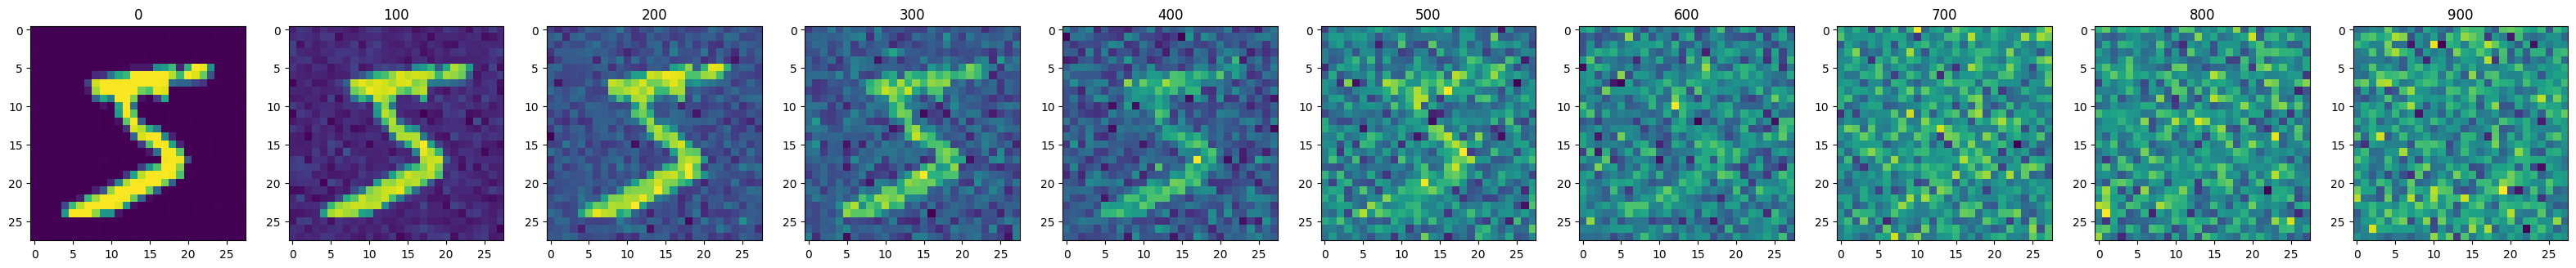

In [5]:
import matplotlib.pyplot as plt


def show_noising_mnist(noise_generator: NoiseGenerator, img: torch.Tensor):
    _, axs = plt.subplots(1, 10, figsize=(40, 5))
    for i, t in enumerate(np.linspace(0, noise_generator.T, 10, endpoint=False)):
        t = int(round(t))
        x = noise_generator.forward(img, t=torch.tensor([t] * img.shape[0]))
        axs[i].imshow(X=x["x_t"][0][0].cpu().detach().numpy())
        axs[i].set(title=t)


show_noising_mnist(
    noise_generator, train_dataset[0][0][None, ...].to(device=noise_generator._device)
)

#### Расшумление

Тут повеселее, потому что формула сложнее:
$$
x_{t-1} = \cfrac{1}{\sqrt{\alpha_t}} \left(
    x_t - \cfrac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}}\, \varepsilon_\theta (x_t, t)
\right)
+ \sigma_t z
$$
Где $z \sim \mathcal{N} (0, I)$, $\varepsilon_\theta (x_t, t)$ — выход модели,
$\sigma_t$ — некий параметр подгона, чтобы не давать дисперсии разрастаться.

В статье брали $\sigma_t = \sqrt{\beta_t}$, мы будем делать так же (авторы подобрали это экспериментально).

In [6]:
import torch.nn as nn
import tqdm


class Denoiser:
    def __init__(self, backbone: nn.Module, noise_generator: NoiseGenerator):
        super().__init__()
        self.noise_generator = noise_generator
        self._c = self.noise_generator.coeffs
        self._device = noise_generator._device
        self.backbone = backbone.to(self._device)

    @torch.no_grad()
    def one_step(self, x_t: torch.Tensor, t: torch.Tensor, y: torch.Tensor):
        # Помним, что на каждом шаге расшумления впрыскивается шум
        noise = torch.randn_like(x_t, device=self._device)
        # Модель будет предсказывать epsilon_t
        model_output = self.backbone(x_t, t, y)

        # На шаге t = 0 шум не добавляется
        mask = (1 * (t != 0))[:, None, None, None]
        sigma_t = self._c.sqrt_betas[t][:, None, None, None]

        x_prev = (
            1
            / self._c.sqrt_alphas[t][:, None, None, None]
            * (
                x_t
                # Добавим ось вдоль времени
                - model_output
                * self._c.betas[t][:, None, None, None]
                / self._c.sqrt_1m_alphas_hat[t][:, None, None, None]
            )
            + mask * sigma_t * noise
        )
        return x_prev

    @torch.no_grad()
    def sample(
        self,
        shape: tuple[int, ...],
        y: torch.Tensor | None = None,
        store_images: bool = False,
    ):
        self.backbone.eval()
        x_t = torch.randn(shape, device=self._device)
        images = []
        if y is None:
            y = torch.randint(0, 10, (shape[0],), device=self._device)
        batch_size = shape[0]
        # Идём 1000 шагов с конца и восстанавливем x_0
        for t in tqdm.trange(self.noise_generator.T - 1, -1, -1):
            t_tensor = (
                torch.ones(batch_size, dtype=torch.int64, device=self._device) * t
            )
            x_t = self.one_step(x_t, t_tensor, y)
            if store_images:
                images.append(x_t.cpu())
        return x_t, images

In [7]:
from utils import UNetDiffusion

model = UNetDiffusion().to(device=noise_generator._device)
# model.load_state_dict(torch.load("model_good.pt"))

In [8]:
with torch.no_grad():
    print(
        model(
            train_dataset[0][0][None, ...].to(noise_generator._device),
            torch.tensor([0], device=noise_generator._device),
            torch.tensor([train_dataset[0][1]], device=noise_generator._device),
        ).shape
    )

torch.Size([1, 1, 28, 28])


In [9]:
# Проверим, всё ли работает
# model = Unet(dim=64, dim_mults=(1, 2, 4, 4), channels=1, flash_attn=False)
one_image = train_dataset[0][0][None, ...]
# with torch.no_grad():
#     print(model(one_image, torch.tensor([2])).shape)

denoiser = Denoiser(model, noise_generator=noise_generator)
print(denoiser.sample((2, 1, 28, 28))[0].shape)

100%|██████████| 1000/1000 [00:02<00:00, 402.16it/s]

torch.Size([2, 1, 28, 28])


#### Идём учить

torch.Size([1, 1, 28, 28])


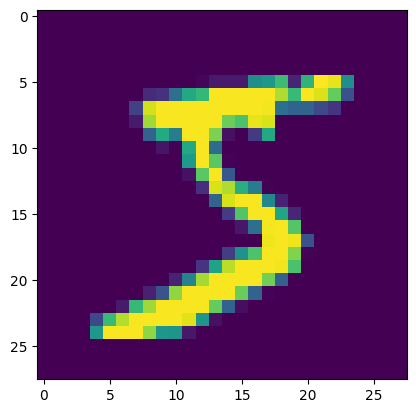

In [10]:
import matplotlib.pyplot as plt

one_image = train_dataset[0][0][None, ...]
print(one_image.shape)
plt.imshow(one_image.numpy()[0][0])

In [11]:
import wandb

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
device = denoiser._device

wandb.init(project="startdl", name="cv-lesson-12")
wandb.watch(model)
epochs = 50
with tqdm.tqdm(total=epochs * len(train_loader)) as pbar:
    for epoch in range(50):
        for step, (image, label) in enumerate(train_loader):
            image, label = image.to(device), label.to(device)
            # 1000 — число степов
            t_tensor = torch.randint(
                low=0, high=1000, size=(image.shape[0],), device=device
            )
            eps = torch.randn_like(image, device=device)
            model_input = noise_generator.forward(image, t_tensor, eps)["x_t"]
            eps_pred = denoiser.backbone(model_input, t_tensor, label)
            optimizer.zero_grad()
            loss = criterion(eps_pred, eps)
            loss.backward()
            optimizer.step()

            _loss = loss.item()
            pbar.update(1)
            pbar.set_description(
                f"Epoch: {epoch} / {epochs} | Iter: {step} / {len(train_loader)}"
            )
            wandb.log({"loss": _loss})

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: alekseik1. Use `wandb login --relogin` to force relogin


Epoch: 49 / 50 | Iter: 468 / 469: 100%|██████████| 23450/23450 [06:12<00:00, 63.02it/s]


In [12]:
torch.save(model.state_dict(), "model-mnist.pt")

In [13]:
model.load_state_dict(torch.load("model-mnist.pt"))

<All keys matched successfully>

In [14]:
denoiser = Denoiser(model, noise_generator=noise_generator)

In [15]:
rows = 10
y = torch.tensor([i // rows for i in range(rows * rows)], device=denoiser._device)
sampled, intermediate_images = denoiser.sample(
    (rows * rows, 1, 28, 28), y=y, store_images=True
)
sampled = sampled.cpu()
intermediate_images = [x.cpu() for x in intermediate_images]

100%|██████████| 1000/1000 [00:03<00:00, 308.34it/s]


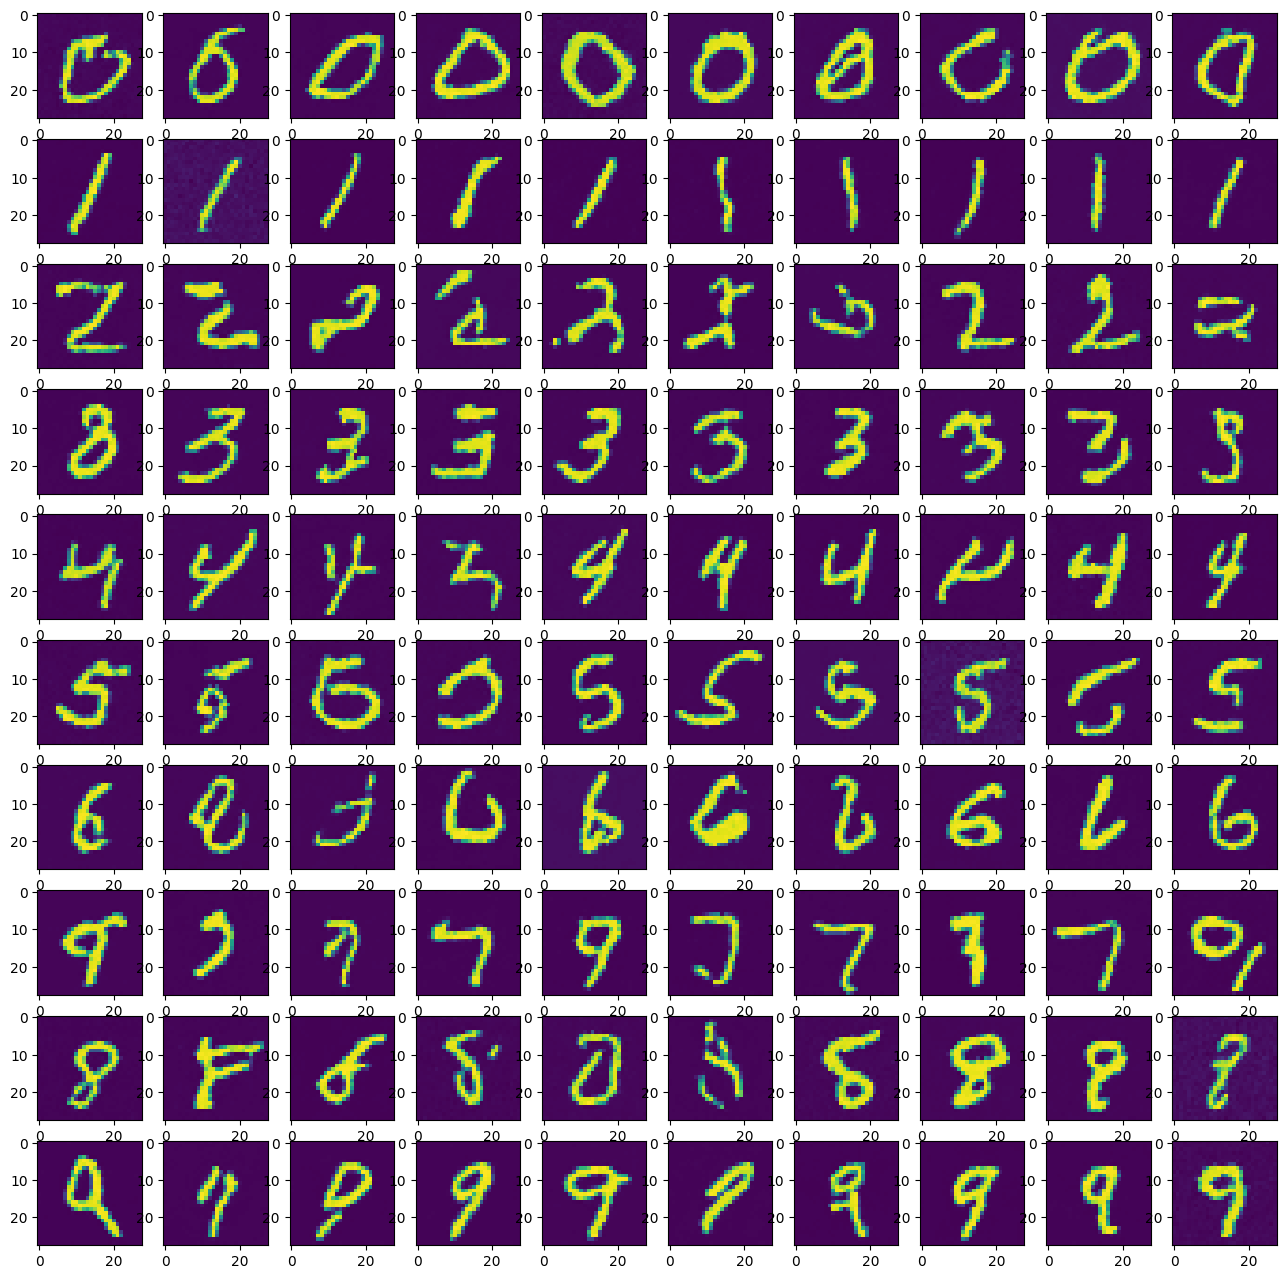

In [16]:
fig, ax = plt.subplots(rows, rows, figsize=(16, 16))
for i, x in enumerate(sampled):
    ax[i // rows][i % rows].imshow(x.numpy()[0])
plt.show()

In [23]:
# Посмотрим, как происходит расшумление
from itertools import chain
from io import BytesIO

from IPython.display import clear_output, display
from ipywidgets import interact
from PIL import Image


def create_sample_images(images: list[torch.Tensor]):
    # (time, channeles, width, height)
    rv = []
    for i in chain(range(0, len(images), 10), [len(images) - 1]):
        fig, ax = plt.subplots()
        ax.imshow(images[i][0].numpy())
        # ax.legend()
        ax.set_title(f"t={i}")
        buf = BytesIO()
        fig.savefig(buf, format="png")
        buf.seek(0)
        rv.append(Image.open(buf))
        plt.close(fig)
    return rv


def show_image(index: int):
    clear_output(wait=True)
    display(figures[index])


one_sample = [x[34] for x in intermediate_images]
figures = create_sample_images(one_sample)
interact(show_image, index=(0, len(figures) - 1));

interactive(children=(IntSlider(value=50, description='index'), Output()), _dom_classes=('widget-interact',))

## Другие диффузионные модели

После публикации статьи DDPM (июнь 2020 года) вышло огромное множество других диффузионных моделей.

К счастью, HuggingFace быстро подхватил тренд и создал площадку для доступа к большому количеству моделей — [Diffusers](https://huggingface.co/docs/diffusers/index), а также одноимённую [библиотеку](https://github.com/huggingface/diffusers).

Посмотрим, как ею пользоваться.

In [18]:
from diffusers import DiffusionPipeline
import torch

pipeline = DiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16
)
pipeline.to("cuda")

Could not find the bitsandbytes CUDA binary at PosixPath('/home/aleksei/.cache/pypoetry/virtualenvs/start-dl-nJVKNwkY-py3.10/lib/python3.10/site-packages/bitsandbytes/libbitsandbytes_cuda121.so')
Could not load bitsandbytes native library: /home/aleksei/.cache/pypoetry/virtualenvs/start-dl-nJVKNwkY-py3.10/lib/python3.10/site-packages/bitsandbytes/libbitsandbytes_cpu.so: cannot open shared object file: No such file or directory
Traceback (most recent call last):
  File "/home/aleksei/.cache/pypoetry/virtualenvs/start-dl-nJVKNwkY-py3.10/lib/python3.10/site-packages/bitsandbytes/cextension.py", line 109, in <module>
    lib = get_native_library()
  File "/home/aleksei/.cache/pypoetry/virtualenvs/start-dl-nJVKNwkY-py3.10/lib/python3.10/site-packages/bitsandbytes/cextension.py", line 96, in get_native_library
    dll = ct.cdll.LoadLibrary(str(binary_path))
  File "/home/aleksei/.pyenv/versions/3.10.15/lib/python3.10/ctypes/__init__.py", line 452, in LoadLibrary
    return self._dlltype(name

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.32.2",
  "_name_or_path": "stable-diffusion-v1-5/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/50 [00:00<?, ?it/s]

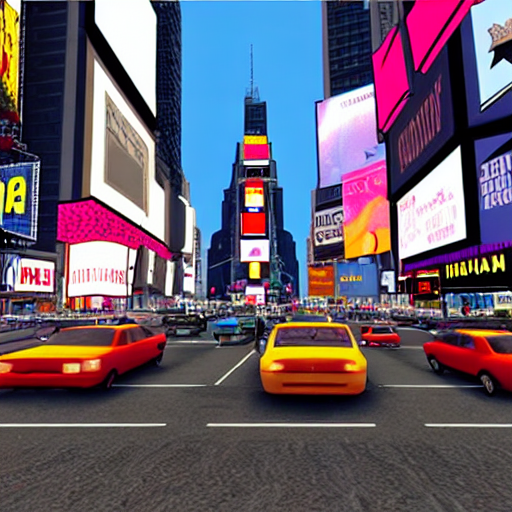

In [19]:
pipeline("A photo of Times Square if it was in GTA").images[0]

100%|██████████| 1000/1000 [00:32<00:00, 30.72it/s]


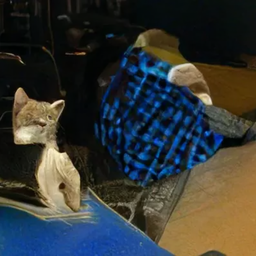

In [20]:
# DiffusionPipeline — это обёртка над Model и Scheduler.
# Model ответственна за предсказание картинки (или шума, как мы видели выше).
# Scheduler ответствен за процесс расшумления.

import torch
from diffusers import DDIMScheduler, DDPMScheduler, UNet2DModel
from PIL import Image

scheduler = DDPMScheduler.from_pretrained("google/ddpm-cat-256")
model = UNet2DModel.from_pretrained("google/ddpm-cat-256").to("cuda")
scheduler.set_timesteps(1000)

sample_size = model.config.sample_size
noise = torch.randn((1, 3, sample_size, sample_size), device="cuda")
input = noise

for t in tqdm.tqdm(scheduler.timesteps):
    with torch.no_grad():
        noisy_residual = model(input, t).sample
        prev_noisy_sample = scheduler.step(noisy_residual, t, input).prev_sample
        input = prev_noisy_sample

image = (input / 2 + 0.5).clamp(0, 1)
image = image.cpu().permute(0, 2, 3, 1).numpy()[0]
image = Image.fromarray((image * 255).round().astype("uint8"))
image

In [21]:
scheduler

DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.32.2",
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_start": 0.0001,
  "clip_sample": true,
  "clip_sample_range": 1.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}

In [22]:
model

UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Con

## Итоги
1. Вспомнили принципы GAN, посмотрели демо StyleGAN3.
2. Закодили DDPM, обучили, получили хорошее качество на MNIST.
3. Посмотрели работу библиотеки `diffusers`, попробовали разные модели и шедулеры.